## Step 1: Data Understanding and Structuring

### Step 1.1: Data Understanding and Validation

This step focuses on exploring and validating the dataset before any preprocessing or modeling.

The dataset consists of:

* Chest X-ray images
* Segmentation masks highlighting pneumonia regions
* Metadata and labels stored in a CSV file

The objectives of this step are:

* Verify dataset structure and integrity
* Understand annotation format and label distribution
* Analyze missing values
* Ensure correct alignment between images and masks
* Visualize sample data for qualitative understanding

This step is essential to prevent inconsistencies and ensure that subsequent experiments are reliable.


In [2]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Define dataset paths (Kaggle format)set
DATA_DIR = "/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset"

IMAGE_DIR = os.path.join(DATA_DIR, "Training", "Images")
MASK_DIR = os.path.join(DATA_DIR, "Training", "Masks")
LABEL_PATH = os.path.join(DATA_DIR, "stage2_train_metadata.csv")

# Verify paths
print("Image dir exists:", os.path.exists(IMAGE_DIR))
print("Mask dir exists:", os.path.exists(MASK_DIR))
print("CSV exists:", os.path.exists(LABEL_PATH))

Image dir exists: True
Mask dir exists: True
CSV exists: True


In [4]:
# Load CSV file
df = pd.read_csv(LABEL_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (30227, 11)


,patientId,x,y,width,height,Target,class,age,sex,modality,position
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,51,F,CR,PA
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,48,F,CR,PA
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,19,M,CR,AP
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal,28,M,CR,PA
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,Lung Opacity,32,F,CR,AP


In [5]:
# Inspect columns
print(df.columns)

Index(['patientId', 'x', 'y', 'width', 'height', 'Target', 'class', 'age',
       'sex', 'modality', 'position'],
      dtype='object')


In [6]:
# Check missing values
df.isnull().sum()

# Missing bounding box values correspond to normal cases

patientId        0
x            20672
y            20672
width        20672
height       20672
Target           0
class            0
age              0
sex              0
modality         0
position         0
dtype: int64

In [7]:
# Check class distribution
df['Target'].value_counts()

# Helps identify imbalance between pneumonia and normal

Target
0    20672
1     9555
Name: count, dtype: int64

In [8]:
# Count unique patients
print("Unique patient IDs:", df['patientId'].nunique())

Unique patient IDs: 26684


In [9]:
# List image and mask files
images = os.listdir(IMAGE_DIR)
masks = os.listdir(MASK_DIR)

print("Total images:", len(images))
print("Total masks:", len(masks))

print("Sample images:", images[:5])
print("Sample masks:", masks[:5])

Total images: 26684
Total masks: 26684
Sample images: ['7a530f4d-13af-4e4e-bf2e-080c7fb27ffb.png', '86f084ef-539c-404b-9a91-c9a5d5ab3771.png', '673989cb-131a-43fc-8276-710c65ddb2d6.png', '85a77a2c-9fb8-4ceb-af2b-4de716d4d366.png', '9f756055-99fc-4a80-97b4-f89f98cf92d2.png']
Sample masks: ['7a530f4d-13af-4e4e-bf2e-080c7fb27ffb.png', '86f084ef-539c-404b-9a91-c9a5d5ab3771.png', '673989cb-131a-43fc-8276-710c65ddb2d6.png', '85a77a2c-9fb8-4ceb-af2b-4de716d4d366.png', '9f756055-99fc-4a80-97b4-f89f98cf92d2.png']


In [10]:
# Check matching between images and masks
common_files = set(images).intersection(set(masks))

print("Matching files:", len(common_files))
print("Images without masks:", len(set(images) - set(masks)))
print("Masks without images:", len(set(masks) - set(images)))

# Filenames must match for correct pairing

Matching files: 26684
Images without masks: 0
Masks without images: 0


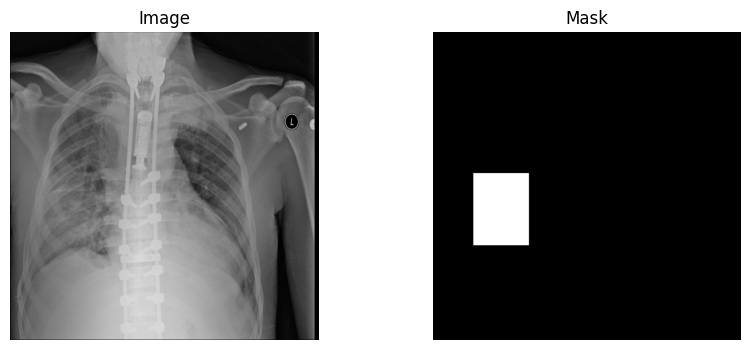

In [11]:
# Display one image and its mask
sample = images[0]

img_path = os.path.join(IMAGE_DIR, sample)
mask_path = os.path.join(MASK_DIR, sample)

image = cv2.imread(img_path, 0)
mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis('off')

plt.show()

### Step 1.1: Observations

* The dataset contains both image-level labels and pixel-level annotations (masks).
* Missing bounding box values correspond to normal (non-pneumonia) cases.
* Multiple rows exist for a single patient due to multiple annotated regions.
* Images and masks are perfectly aligned, with matching filenames and counts.
* Pneumonia regions occupy a small portion of the image, while most of the image consists of irrelevant background.

These observations indicate that localization-aware methods may improve classification performance.


## Step 1.2: Data Structuring

### Purpose:
The dataset currently contains multiple rows per patient due to multiple bounding boxes.
However, each patient corresponds to a single image.

### This mismatch can lead to:
- Duplicate images during training
- Incorrect labels
- Biased model learning

### Goal:
Convert dataset into a clean format with:
- One row per patient (one image)
- Correct label assignment
- Image and mask paths aligned

### Approach:
- Group by patientId
- Use max(Target) to assign label
- Keep relevant metadata

In [12]:
# Group dataset to one row per patient
grouped_df = df.groupby('patientId').agg({
    'Target': 'max',
    'class': 'first',
    'age': 'first',
    'sex': 'first',
    'position': 'first'
}).reset_index()

print("New dataset shape:", grouped_df.shape)
grouped_df.head()

New dataset shape: (26684, 6)


,patientId,Target,class,age,sex,position
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal,51,F,PA
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,19,F,AP
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,25,F,AP
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity,40,M,AP
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Lung Opacity,57,M,PA


In [13]:
# Verify no duplicates remain
print("Unique patient IDs:", grouped_df['patientId'].nunique())
print("Total rows:", len(grouped_df))

Unique patient IDs: 26684
Total rows: 26684


In [14]:
# Add file paths for images and masks
grouped_df['image_path'] = grouped_df['patientId'].apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".png")
)

grouped_df['mask_path'] = grouped_df['patientId'].apply(
    lambda x: os.path.join(MASK_DIR, x + ".png")
)

grouped_df.head()

,patientId,Target,class,age,sex,position,image_path,mask_path
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal,51,F,PA,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,19,F,AP,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,25,F,AP,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity,40,M,AP,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Lung Opacity,57,M,PA,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...


In [15]:
# Validate file paths
print(os.path.exists(grouped_df['image_path'][0]))
print(os.path.exists(grouped_df['mask_path'][0]))

True
True


In [16]:
# Check class distribution after structuring
grouped_df['Target'].value_counts()

Target
0    20672
1     6012
Name: count, dtype: int64

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

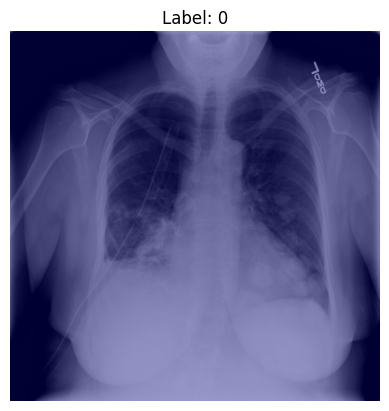

In [17]:
# Visual verification of structured dataset
row = grouped_df.iloc[0]

img = cv2.imread(row['image_path'], 0)
mask = cv2.imread(row['mask_path'], 0)

plt.imshow(img, cmap='gray')
plt.imshow(mask, cmap='jet', alpha=0.4)
plt.title(f"Label: {row['Target']}")
plt.axis('off')

In [20]:
# Save structured dataset
grouped_df.to_csv("grouped_data.csv", index=False)

print("Saved grouped_data.csv")

Saved grouped_data.csv


### Step 1.2: Observations

* The dataset was successfully reduced to one row per patient.
* The number of rows now matches the number of unique patient IDs.
* Positive cases decreased after aggregation, indicating that multiple annotations per patient were merged correctly.
* Image and mask paths are correctly aligned for each patient.
* The dataset still exhibits class imbalance, with significantly more normal cases than pneumonia cases.

This structured dataset forms a reliable foundation for further preprocessing and modeling.
